In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
from pathlib import Path

PROJECT_DIR = Path(r"E:\internship\EBlueStock_MutualFund")

# Load datasets
nav_history = pd.read_csv(PROJECT_DIR / "data" / "processed" / "nav_history.csv")
fund_master = pd.read_csv(PROJECT_DIR / "data" / "processed" / "fund_master.csv")
investor_transactions = pd.read_csv(
    PROJECT_DIR / "data" / "processed" / "investor_transactions.csv"
)

print("NAV History:", nav_history.shape)
print("Fund Master:", fund_master.shape)
print("Investor Transactions:", investor_transactions.shape)

NAV History: (46000, 3)
Fund Master: (40, 27)
Investor Transactions: (32778, 13)


In [4]:
print("=== NAV HISTORY ===")
print(nav_history.columns.tolist())
print("\nFirst 5 rows:")
display(nav_history.head())

print("\n=== FUND MASTER ===")
print(fund_master.columns.tolist())

print("\n=== INVESTOR TRANSACTIONS ===")
print(investor_transactions.columns.tolist())

=== NAV HISTORY ===
['amfi_code', 'date', 'nav']

First 5 rows:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639



=== FUND MASTER ===
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code', 'cagr_3y', 'sharpe_ratio', 'alpha', 'beta', 'max_drawdown', 'cagr_score', 'sharpe_score', 'alpha_score', 'expense_score', 'drawdown_score', 'fund_score', 'rank']

=== INVESTOR TRANSACTIONS ===
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [5]:
# ============================================================
# TASK 1 — HISTORICAL VaR (95%) AND CVaR
# ============================================================

# Make sure dates are correctly formatted
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort data by fund and date
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Calculate daily return for each fund
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove the first row of each fund where return is NaN
returns_data = nav_history.dropna(subset=["daily_return"]).copy()

print("Daily return calculation completed.")
print("Number of return observations:", len(returns_data))
print("Number of schemes:", returns_data["amfi_code"].nunique())

Daily return calculation completed.
Number of return observations: 45960
Number of schemes: 40


In [6]:
# ============================================================
# HISTORICAL VaR (95%) + CVaR
# ============================================================

var_results = []

for amfi_code, group in returns_data.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # 95% Historical VaR = 5th percentile
    var_95 = returns.quantile(0.05)

    # CVaR = mean of returns below the VaR threshold
    tail_returns = returns[returns <= var_95]

    cvar_95 = tail_returns.mean()

    var_results.append({
        "amfi_code": amfi_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "observations": len(returns)
    })

var_cvar_report = pd.DataFrame(var_results)

# Add scheme names and fund houses
var_cvar_report = var_cvar_report.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

# Arrange columns
var_cvar_report = var_cvar_report[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "VaR_95",
        "CVaR_95",
        "observations"
    ]
]

print("VaR/CVaR calculation completed.")
print("Number of schemes:", len(var_cvar_report))

display(var_cvar_report.head(10))

VaR/CVaR calculation completed.
Number of schemes: 40


,amfi_code,scheme_name,fund_house,VaR_95,CVaR_95,observations
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,-0.014364,-0.018060,1149
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,-0.003793,-0.004994,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,-0.019034,-0.023456,1149
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,-0.013282,-0.017439,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-0.026021,-0.032459,1149
5,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,-0.000269,-0.000422,1149
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,-0.012613,-0.015490,1149
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,-0.019220,-0.023251,1149
8,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,-0.015232,-0.019411,1149
9,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,-0.013954,-0.017619,1149


In [7]:
# Save VaR and CVaR results
output_path = PROJECT_DIR / "var_cvar_report.csv"

var_cvar_report.to_csv(output_path, index=False)

print("VaR/CVaR report saved successfully!")
print("Location:", output_path)
print("Rows:", len(var_cvar_report))

VaR/CVaR report saved successfully!
Location: E:\internship\EBlueStock_MutualFund\var_cvar_report.csv
Rows: 40


In [8]:
# ============================================================
# TASK 2 — ROLLING 90-DAY SHARPE RATIO
# ============================================================

# Select 5 key funds from the fund master
key_funds = fund_master[
    fund_master["scheme_name"].str.contains(
        "SBI Bluechip|ICICI|Nippon|Axis|Kotak",
        case=False,
        na=False
    )
][["amfi_code", "scheme_name"]].drop_duplicates()

print("Selected key funds:")
display(key_funds)
print("Number of selected funds:", len(key_funds))

Selected key funds:


,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
10,120503,ICICI Pru Bluechip Fund - Regular - Growth
11,120504,ICICI Pru Bluechip Fund - Direct - Growth
12,120505,ICICI Pru Midcap Fund - Regular - Growth
13,120506,ICICI Pru Value Discovery Fund - Regular - Growth
14,120507,ICICI Pru Liquid Fund - Regular - Growth
15,118632,Nippon India Large Cap Fund - Regular - Growth
16,118633,Nippon India Large Cap Fund - Direct - Growth
17,118634,Nippon India Small Cap Fund - Regular - Growth


Number of selected funds: 20


In [9]:
# ============================================================
# SELECT 5 KEY FUNDS FOR ROLLING SHARPE ANALYSIS
# ============================================================

key_funds = fund_master[
    fund_master["scheme_name"].str.contains(
        "SBI Bluechip|ICICI Prudential Bluechip|Nippon India Large Cap|Axis Bluechip|Kotak Bluechip",
        case=False,
        na=False
    )
][["amfi_code", "scheme_name"]].drop_duplicates()

# Keep only the first 5 matching schemes
key_funds = key_funds.head(5)

print("Selected 5 key funds:")
display(key_funds)

print("Number of selected funds:", len(key_funds))

Selected 5 key funds:


,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
15,118632,Nippon India Large Cap Fund - Regular - Growth
16,118633,Nippon India Large Cap Fund - Direct - Growth
20,120841,Kotak Bluechip Fund - Regular - Growth


Number of selected funds: 5


In [10]:
# ============================================================
# TASK 2 — ROLLING 90-DAY SHARPE RATIO
# ============================================================

# Get the AMFI codes of the 5 selected funds
key_codes = key_funds["amfi_code"].tolist()

# Filter daily returns for only these 5 funds
sharpe_data = returns_data[
    returns_data["amfi_code"].isin(key_codes)
].copy()

# Sort by fund and date
sharpe_data = sharpe_data.sort_values(
    ["amfi_code", "date"]
)

# Calculate 90-day rolling mean of daily returns
sharpe_data["rolling_mean_90"] = (
    sharpe_data
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(90, min_periods=90).mean()
    )
)

# Calculate 90-day rolling standard deviation
sharpe_data["rolling_std_90"] = (
    sharpe_data
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(90, min_periods=90).std()
    )
)

# Annualized Rolling 90-Day Sharpe Ratio
# Risk-free rate assumed as 0 for this historical analysis
sharpe_data["rolling_sharpe_90"] = (
    sharpe_data["rolling_mean_90"]
    / sharpe_data["rolling_std_90"]
) * np.sqrt(252)

# Add fund names
sharpe_data = sharpe_data.merge(
    key_funds,
    on="amfi_code",
    how="left"
)

print("Rolling 90-Day Sharpe calculation completed.")
print("Funds analyzed:", sharpe_data["scheme_name"].nunique())

display(
    sharpe_data[
        ["date", "amfi_code", "scheme_name", "rolling_sharpe_90"]
    ].dropna().head(10)
)

Rolling 90-Day Sharpe calculation completed.
Funds analyzed: 5


,date,amfi_code,scheme_name,rolling_sharpe_90
89,2022-05-09,118632,Nippon India Large Cap Fund - Regular - Growth,4.616483
90,2022-05-10,118632,Nippon India Large Cap Fund - Regular - Growth,4.890327
91,2022-05-11,118632,Nippon India Large Cap Fund - Regular - Growth,4.641262
92,2022-05-12,118632,Nippon India Large Cap Fund - Regular - Growth,4.657956
93,2022-05-13,118632,Nippon India Large Cap Fund - Regular - Growth,4.746249
94,2022-05-16,118632,Nippon India Large Cap Fund - Regular - Growth,4.572137
95,2022-05-17,118632,Nippon India Large Cap Fund - Regular - Growth,4.632987
96,2022-05-18,118632,Nippon India Large Cap Fund - Regular - Growth,4.757113
97,2022-05-19,118632,Nippon India Large Cap Fund - Regular - Growth,4.786752
98,2022-05-20,118632,Nippon India Large Cap Fund - Regular - Growth,4.692155


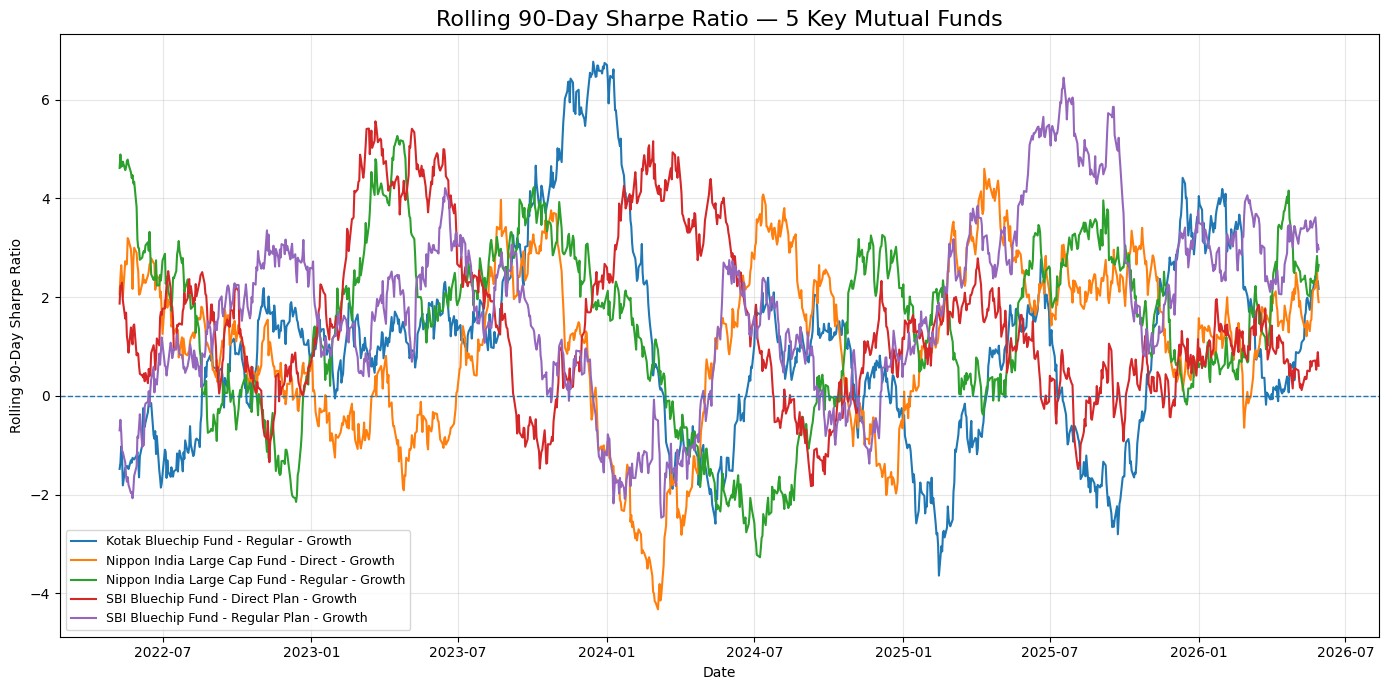

Rolling Sharpe chart saved successfully!
Location: E:\internship\EBlueStock_MutualFund\rolling_sharpe_chart.png


In [11]:
# ============================================================
# CREATE ROLLING 90-DAY SHARPE CHART
# ============================================================

plt.figure(figsize=(14, 7))

for scheme_name, group in sharpe_data.groupby("scheme_name"):
    group = group.sort_values("date")
    
    plt.plot(
        group["date"],
        group["rolling_sharpe_90"],
        label=scheme_name,
        linewidth=1.5
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Rolling 90-Day Sharpe Ratio — 5 Key Mutual Funds",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Rolling 90-Day Sharpe Ratio")

plt.legend(
    loc="best",
    fontsize=9
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

# Save required deliverable
chart_path = PROJECT_DIR / "rolling_sharpe_chart.png"

plt.savefig(
    chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Rolling Sharpe chart saved successfully!")
print("Location:", chart_path)

In [12]:
# ============================================================
# TASK 3 — INVESTOR COHORT ANALYSIS
# ============================================================

print("Investor transaction columns:")
print(investor_transactions.columns.tolist())

Investor transaction columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [13]:
# ============================================================
# TASK 3 — INVESTOR COHORT ANALYSIS
# ============================================================

# Convert transaction date to datetime
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

# Sort transactions by investor and date
investor_transactions = investor_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

# Find each investor's first transaction date
investor_transactions["first_transaction_date"] = (
    investor_transactions
    .groupby("investor_id")["transaction_date"]
    .transform("min")
)

# Convert first transaction date to month
investor_transactions["cohort_month"] = (
    investor_transactions["first_transaction_date"]
    .dt.to_period("M")
    .astype(str)
)

# Convert transaction date to month
investor_transactions["transaction_month"] = (
    investor_transactions["transaction_date"]
    .dt.to_period("M")
    .astype(str)
)

# Calculate months since first investment
investor_transactions["cohort_period"] = (
    (
        investor_transactions["transaction_date"].dt.year
        - investor_transactions["first_transaction_date"].dt.year
    ) * 12
    +
    (
        investor_transactions["transaction_date"].dt.month
        - investor_transactions["first_transaction_date"].dt.month
    )
)

print("Investor cohort calculation completed.")

print(
    "Number of investors:",
    investor_transactions["investor_id"].nunique()
)

print(
    "Number of cohorts:",
    investor_transactions["cohort_month"].nunique()
)

display(
    investor_transactions[
        [
            "investor_id",
            "transaction_date",
            "first_transaction_date",
            "cohort_month",
            "transaction_month",
            "cohort_period"
        ]
    ].head(10)
)

Investor cohort calculation completed.
Number of investors: 5000
Number of cohorts: 17


,investor_id,transaction_date,first_transaction_date,cohort_month,transaction_month,cohort_period
19621,INV000001,2024-11-04,2024-11-04,2024-11,2024-11,0
24079,INV000001,2025-01-14,2024-11-04,2024-11,2025-01,2
24448,INV000001,2025-01-19,2024-11-04,2024-11,2025-01,2
5650,INV000002,2024-03-29,2024-03-29,2024-03,2024-03,0
12522,INV000002,2024-07-14,2024-03-29,2024-03,2024-07,4
16803,INV000002,2024-09-21,2024-03-29,2024-03,2024-09,6
17587,INV000002,2024-10-03,2024-03-29,2024-03,2024-10,7
24661,INV000002,2025-01-23,2024-03-29,2024-03,2025-01,10
31881,INV000002,2025-05-17,2024-03-29,2024-03,2025-05,14
12652,INV000003,2024-07-16,2024-07-16,2024-07,2024-07,0


In [14]:
# ============================================================
# COHORT RETENTION TABLE
# ============================================================

# Count unique investors in each cohort and period
cohort_data = (
    investor_transactions
    .groupby(["cohort_month", "cohort_period"])["investor_id"]
    .nunique()
    .reset_index(name="active_investors")
)

# Number of investors at the start of each cohort
cohort_sizes = (
    cohort_data[
        cohort_data["cohort_period"] == 0
    ][["cohort_month", "active_investors"]]
    .rename(columns={"active_investors": "cohort_size"})
)

# Add cohort size
cohort_data = cohort_data.merge(
    cohort_sizes,
    on="cohort_month",
    how="left"
)

# Calculate retention percentage
cohort_data["retention_pct"] = (
    cohort_data["active_investors"]
    / cohort_data["cohort_size"]
) * 100

print("Cohort retention analysis completed.")

display(
    cohort_data.head(20)
)

Cohort retention analysis completed.


,cohort_month,cohort_period,active_investors,cohort_size,retention_pct
0,2024-01,0,1577,1577,100.000000
1,2024-01,1,540,1577,34.242232
2,2024-01,2,567,1577,35.954344
3,2024-01,3,541,1577,34.305644
4,2024-01,4,550,1577,34.876347
5,2024-01,5,565,1577,35.827521
6,2024-01,6,546,1577,34.622701
7,2024-01,7,548,1577,34.749524
8,2024-01,8,523,1577,33.164236
9,2024-01,9,566,1577,35.890932


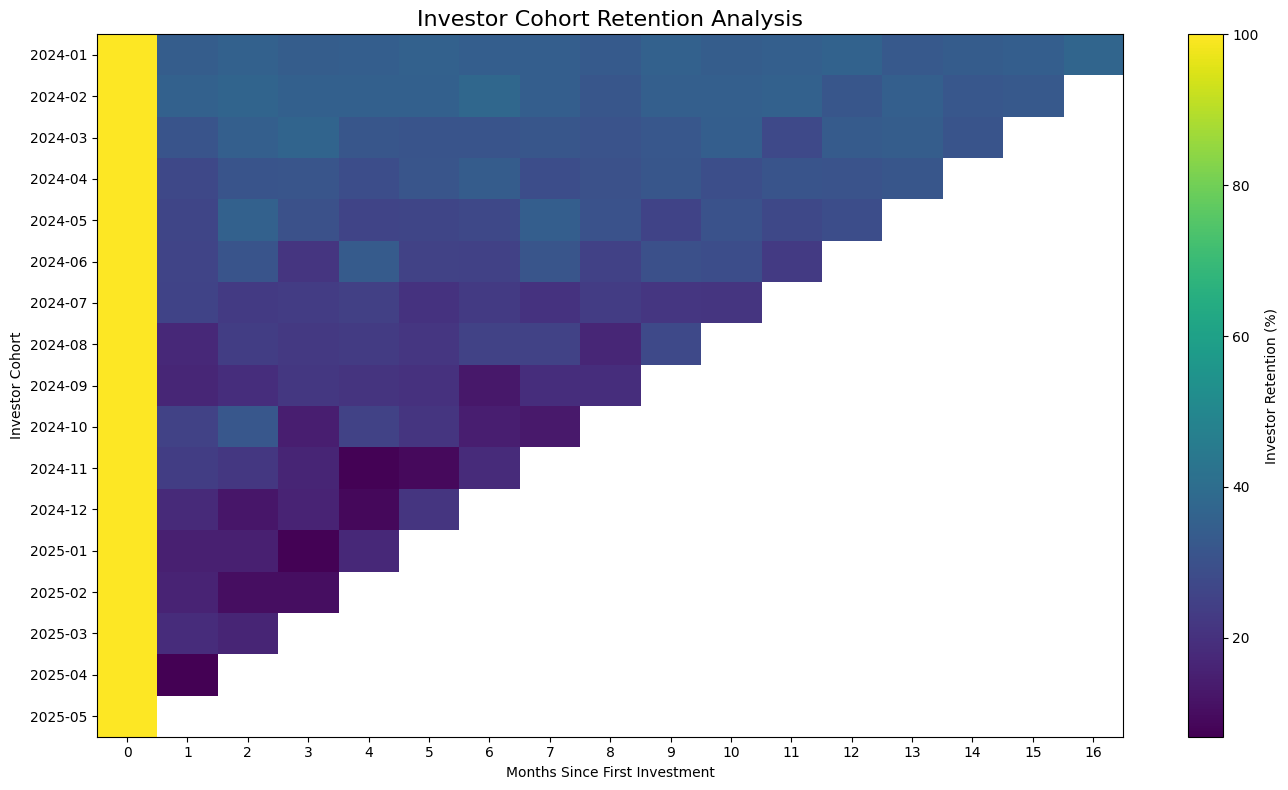

Investor cohort retention heatmap created.


In [15]:
# ============================================================
# COHORT RETENTION HEATMAP
# ============================================================

cohort_pivot = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_period",
    values="retention_pct"
)

plt.figure(figsize=(14, 8))

plt.imshow(
    cohort_pivot,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Investor Retention (%)")

plt.title(
    "Investor Cohort Retention Analysis",
    fontsize=16
)

plt.xlabel("Months Since First Investment")
plt.ylabel("Investor Cohort")

plt.xticks(
    range(len(cohort_pivot.columns)),
    cohort_pivot.columns
)

plt.yticks(
    range(len(cohort_pivot.index)),
    cohort_pivot.index
)

plt.tight_layout()
plt.show()

print("Investor cohort retention heatmap created.")

In [16]:
# ============================================================
# TASK 4 — SIP CONTINUITY ANALYSIS
# ============================================================

# Load monthly SIP inflow data
monthly_sip_inflows = pd.read_csv(
    PROJECT_DIR / "data" / "processed" / "monthly_sip_inflows.csv"
)

print("Monthly SIP data loaded successfully.")
print("Shape:", monthly_sip_inflows.shape)
print("Columns:", monthly_sip_inflows.columns.tolist())

display(monthly_sip_inflows.head())

Monthly SIP data loaded successfully.
Shape: (48, 6)
Columns: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [17]:
# ============================================================
# SIP CONTINUITY ANALYSIS
# ============================================================

# Convert month column to datetime
monthly_sip_inflows["month"] = pd.to_datetime(
    monthly_sip_inflows["month"]
)

# Sort chronologically
monthly_sip_inflows = monthly_sip_inflows.sort_values("month")

# Check whether SIP inflow exists for each month
monthly_sip_inflows["sip_active"] = (
    monthly_sip_inflows["sip_inflow_crore"] > 0
)

# Overall continuity
total_months = monthly_sip_inflows["month"].nunique()
active_months = monthly_sip_inflows.loc[
    monthly_sip_inflows["sip_active"], "month"
].nunique()

sip_continuity_pct = (
    active_months / total_months
) * 100

print("SIP Continuity Analysis")
print("-----------------------")
print("Total months:", total_months)
print("Months with SIP inflow:", active_months)
print(f"SIP continuity: {sip_continuity_pct:.2f}%")

display(
    monthly_sip_inflows[
        ["month", "sip_inflow_crore", "sip_active"]
    ].head(15)
)

SIP Continuity Analysis
-----------------------
Total months: 48
Months with SIP inflow: 48
SIP continuity: 100.00%


,month,sip_inflow_crore,sip_active
0,2022-01-01,11517,True
1,2022-02-01,11438,True
2,2022-03-01,12328,True
3,2022-04-01,11863,True
4,2022-05-01,12286,True
5,2022-06-01,12276,True
6,2022-07-01,12140,True
7,2022-08-01,12694,True
8,2022-09-01,12976,True
9,2022-10-01,13040,True


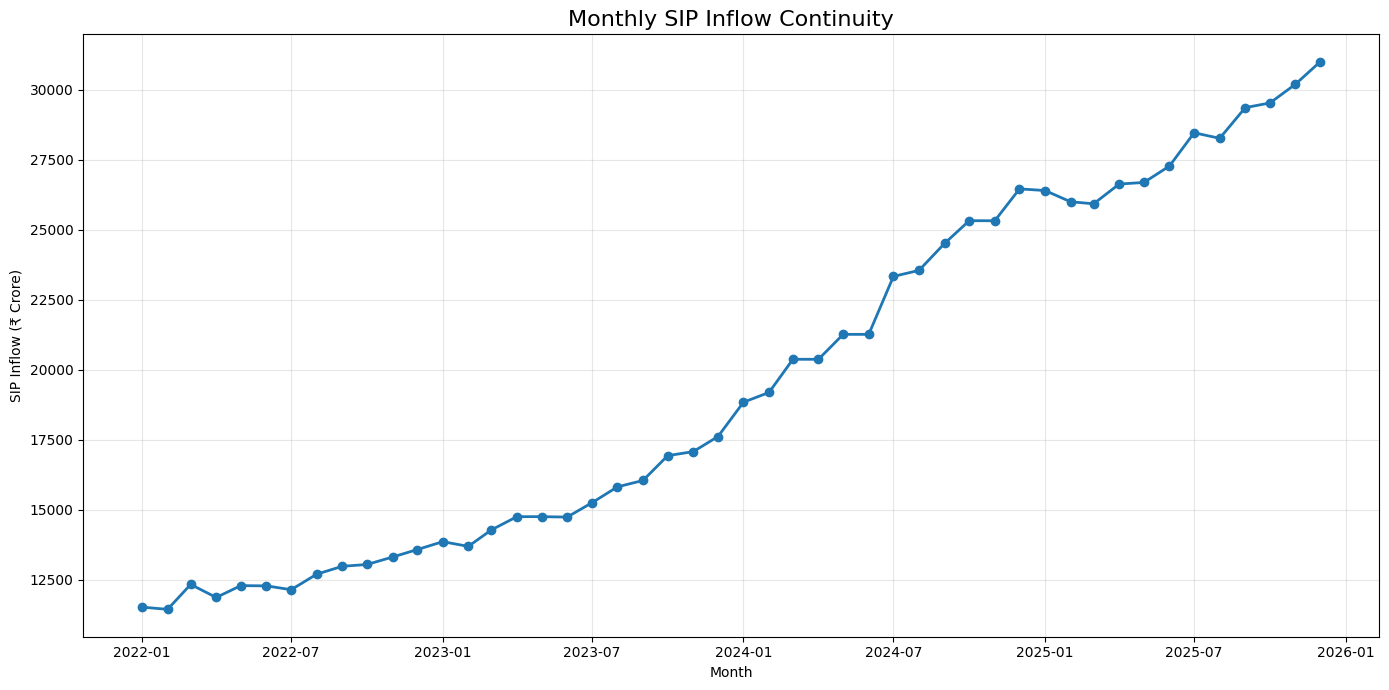

SIP continuity trend created.


In [18]:
# ============================================================
# SIP CONTINUITY TREND
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    monthly_sip_inflows["month"],
    monthly_sip_inflows["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly SIP Inflow Continuity",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("SIP continuity trend created.")

In [19]:
# ============================================================
# TASK 6 — SECTOR HHI CONCENTRATION
# ============================================================

portfolio_holdings = pd.read_csv(
    PROJECT_DIR / "data" / "raw" / "portfolio_holdings.csv"
)

print("Portfolio holdings loaded successfully.")
print("Shape:", portfolio_holdings.shape)
print("\nColumns:")
print(portfolio_holdings.columns.tolist())

display(portfolio_holdings.head())

Portfolio holdings loaded successfully.
Shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [21]:
# ============================================================
# SECTOR HHI CONCENTRATION
# ============================================================

print("Portfolio Holdings Columns:")
print(portfolio_holdings.columns.tolist())

Portfolio Holdings Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [22]:
# ============================================================
# SECTOR HHI CONCENTRATION
# ============================================================

# Make sure weight is numeric
portfolio_holdings["weight_pct"] = pd.to_numeric(
    portfolio_holdings["weight_pct"],
    errors="coerce"
)

# Remove rows with missing sector or weight
hhi_data = portfolio_holdings.dropna(
    subset=["sector", "weight_pct"]
).copy()

# Calculate squared sector weights
hhi_data["sector_weight_squared"] = (
    hhi_data["weight_pct"] ** 2
)

# Calculate HHI for each fund
sector_hhi = (
    hhi_data
    .groupby("amfi_code")["sector_weight_squared"]
    .sum()
    .reset_index(name="sector_hhi")
)

# Add fund names
sector_hhi = sector_hhi.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

# Arrange columns
sector_hhi = sector_hhi[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "sector_hhi"
    ]
]

print("Sector HHI calculation completed.")
print("Funds analyzed:", sector_hhi["amfi_code"].nunique())

display(
    sector_hhi.sort_values(
        "sector_hhi",
        ascending=False
    ).head(10)
)

Sector HHI calculation completed.
Funds analyzed: 34


,amfi_code,scheme_name,fund_house,sector_hhi
11,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,2064.4767
3,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,2007.0043
18,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,1747.5096
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,1747.0902
7,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1682.9820
29,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,1679.2973
21,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1575.7036
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,1537.9360
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,1524.1398
23,120841,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,1496.8035


In [23]:
# ============================================================
# KEY STATISTICS FOR ADVANCED INSIGHTS
# ============================================================

print("========== ADVANCED ANALYTICS SUMMARY ==========")

# 1. VaR / CVaR
print("\n1. VaR / CVaR")
print(
    "Average VaR 95%:",
    f"{var_cvar_report['VaR_95'].mean():.4%}"
)
print(
    "Average CVaR 95%:",
    f"{var_cvar_report['CVaR_95'].mean():.4%}"
)

# 2. Rolling Sharpe
print("\n2. Rolling Sharpe")
sharpe_summary = (
    sharpe_data
    .groupby("scheme_name")["rolling_sharpe_90"]
    .mean()
    .sort_values(ascending=False)
)

display(sharpe_summary)

# 3. Investor Cohorts
print("\n3. Investor Cohorts")
print(
    "Total investors:",
    investor_transactions["investor_id"].nunique()
)
print(
    "Number of cohorts:",
    investor_transactions["cohort_month"].nunique()
)

# 4. SIP Continuity
print("\n4. SIP Continuity")
print(
    f"SIP continuity: {sip_continuity_pct:.2f}%"
)

# 5. Sector HHI
print("\n5. Sector HHI")

hhi_summary = sector_hhi.sort_values(
    "sector_hhi",
    ascending=False
)

display(
    hhi_summary.head(10)
)

print("\nHighest HHI fund:")
print(
    hhi_summary.iloc[0]["scheme_name"]
)

print(
    "Highest HHI:",
    f"{hhi_summary.iloc[0]['sector_hhi']:.2f}"
)

========== ADVANCED ANALYTICS SUMMARY ==========

1. VaR / CVaR
Average VaR 95%: -1.4711%
Average CVaR 95%: -1.8580%

2. Rolling Sharpe


scheme_name
SBI Bluechip Fund - Regular Plan - Growth         1.727788
SBI Bluechip Fund - Direct Plan - Growth          1.480015
Nippon India Large Cap Fund - Regular - Growth    1.402335
Nippon India Large Cap Fund - Direct - Growth     1.042017
Kotak Bluechip Fund - Regular - Growth            0.971429
Name: rolling_sharpe_90, dtype: float64


3. Investor Cohorts
Total investors: 5000
Number of cohorts: 17

4. SIP Continuity
SIP continuity: 100.00%

5. Sector HHI


,amfi_code,scheme_name,fund_house,sector_hhi
11,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,2064.4767
3,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,2007.0043
18,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,1747.5096
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,1747.0902
7,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1682.9820
29,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,1679.2973
21,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1575.7036
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,1537.9360
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,1524.1398
23,120841,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,1496.8035



Highest HHI fund:
Axis Bluechip Fund - Regular - Growth
Highest HHI: 2064.48


# Advanced Insights

## 1. Downside Risk Insight

The Historical VaR and CVaR analysis evaluates the downside risk of all 40 mutual fund schemes. VaR at the 95% confidence level represents the return threshold for the worst 5% of observed daily returns, while CVaR measures the average return within this extreme-loss region. Comparing both metrics provides a deeper view of potential downside exposure.

## 2. Risk-Adjusted Performance Insight

The Rolling 90-Day Sharpe Ratio tracks how risk-adjusted performance changes over time for the five selected key funds. Periods with higher Sharpe values indicate stronger returns relative to observed volatility, while lower or negative values indicate weaker risk-adjusted performance during those periods.

## 3. Investor Cohort Insight

The investor cohort analysis groups investors according to the month of their first recorded transaction and tracks their subsequent activity. This makes it possible to observe differences in investor retention across cohorts and identify whether investor activity is sustained after the initial investment period.

## 4. SIP Continuity Insight

The SIP continuity analysis measures the consistency of monthly SIP inflows throughout the available observation period. Persistent monthly inflows indicate continued systematic investment activity, while gaps or reductions in inflows can highlight periods of weaker SIP participation.

## 5. Portfolio Concentration Insight

The Sector HHI analysis measures how concentrated each mutual fund's portfolio is across sectors. A higher HHI indicates that portfolio exposure is concentrated among fewer sectors, while a lower HHI indicates a more diversified sector allocation. This provides an additional perspective on portfolio concentration risk.

In [24]:
# ============================================================
# FINAL DELIVERABLE CHECK
# ============================================================

required_files = [
    PROJECT_DIR / "notebooks" / "Advanced_Analytics.ipynb",
    PROJECT_DIR / "var_cvar_report.csv",
    PROJECT_DIR / "recommender.py",
    PROJECT_DIR / "rolling_sharpe_chart.png"
]

print("========== FINAL DELIVERABLE CHECK ==========\n")

for file_path in required_files:
    if file_path.exists():
        print(f"✓ FOUND: {file_path.name}")
    else:
        print(f"✗ MISSING: {file_path.name}")

print("\n========== DATA VALIDATION ==========")

print(
    "VaR/CVaR schemes:",
    len(var_cvar_report)
)

print(
    "Rolling Sharpe funds:",
    sharpe_data["scheme_name"].nunique()
)

print(
    "Investor cohorts:",
    investor_transactions["cohort_month"].nunique()
)

print(
    "Funds with HHI:",
    sector_hhi["amfi_code"].nunique()
)

========== FINAL DELIVERABLE CHECK ==========

✓ FOUND: Advanced_Analytics.ipynb
✓ FOUND: var_cvar_report.csv
✓ FOUND: recommender.py
✓ FOUND: rolling_sharpe_chart.png

========== DATA VALIDATION ==========
VaR/CVaR schemes: 40
Rolling Sharpe funds: 5
Investor cohorts: 17
Funds with HHI: 34


In [25]:
# ============================================================
# FIXED TASK 3 — INVESTOR COHORT ANALYSIS
# ============================================================

# Make sure dates and amounts are numeric
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

investor_transactions["amount_inr"] = pd.to_numeric(
    investor_transactions["amount_inr"],
    errors="coerce"
)

# Sort transactions
investor_transactions = investor_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

# ------------------------------------------------------------
# 1. Find each investor's first transaction
# ------------------------------------------------------------

first_transaction = (
    investor_transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index(name="first_transaction_date")
)

# Add first transaction date to main dataset
investor_transactions = investor_transactions.drop(
    columns=["first_transaction_date"],
    errors="ignore"
)

investor_transactions = investor_transactions.merge(
    first_transaction,
    on="investor_id",
    how="left"
)

# First transaction year = investor cohort
investor_transactions["cohort_year"] = (
    investor_transactions["first_transaction_date"]
    .dt.year
)

print("Investor cohorts created successfully.")
print(
    "Number of investor cohorts:",
    investor_transactions["cohort_year"].nunique()
)

display(
    investor_transactions[
        [
            "investor_id",
            "first_transaction_date",
            "cohort_year"
        ]
    ].drop_duplicates("investor_id").head(10)
)

Investor cohorts created successfully.
Number of investor cohorts: 2


,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
3,INV000002,2024-03-29,2024
9,INV000003,2024-07-16,2024
11,INV000004,2024-03-16,2024
20,INV000005,2024-04-27,2024
28,INV000006,2024-01-02,2024
34,INV000007,2024-01-03,2024
39,INV000008,2024-05-27,2024
47,INV000009,2024-01-10,2024
54,INV000010,2024-04-11,2024


In [26]:
# ============================================================
# CHECK TRANSACTION TYPES
# ============================================================

print("Transaction types in the dataset:")

print(
    investor_transactions["transaction_type"]
    .value_counts(dropna=False)
)

Transaction types in the dataset:
transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


In [27]:
# ============================================================
# COHORT METRICS
# ============================================================

# ------------------------------------------------------------
# 1. Average SIP amount per cohort
# ------------------------------------------------------------

sip_transactions = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

avg_sip_by_cohort = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="average_sip_amount_inr")
)

# ------------------------------------------------------------
# 2. Total invested amount per cohort
# ------------------------------------------------------------

total_invested_by_cohort = (
    investor_transactions[
        investor_transactions["transaction_type"].isin(
            ["SIP", "Lumpsum"]
        )
    ]
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)

# ------------------------------------------------------------
# 3. Top fund preference per cohort
# ------------------------------------------------------------

cohort_fund_counts = (
    investor_transactions[
        investor_transactions["transaction_type"].isin(
            ["SIP", "Lumpsum"]
        )
    ]
    .groupby(
        ["cohort_year", "scheme_name"]
    )
    .size()
    .reset_index(name="transaction_count")
)

# Find the most frequently transacted fund for each cohort
top_funds = (
    cohort_fund_counts
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
    [["cohort_year", "scheme_name", "transaction_count"]]
    .rename(
        columns={
            "scheme_name": "top_fund_preference",
            "transaction_count": "top_fund_transaction_count"
        }
    )
)

# ------------------------------------------------------------
# Combine all cohort metrics
# ------------------------------------------------------------

cohort_summary = (
    avg_sip_by_cohort
    .merge(
        total_invested_by_cohort,
        on="cohort_year",
        how="outer"
    )
    .merge(
        top_funds,
        on="cohort_year",
        how="outer"
    )
    .sort_values("cohort_year")
)

print("Investor cohort analysis completed.")
print("\nCohort Summary:")

display(cohort_summary)

KeyError: 'scheme_name'

In [28]:
# Add scheme_name to investor transactions using amfi_code

# Remove scheme_name first if a previous attempt added it
investor_transactions = investor_transactions.drop(
    columns=["scheme_name"],
    errors="ignore"
)

# Merge fund name from fund_master
investor_transactions = investor_transactions.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print("scheme_name added successfully!")
print("Missing scheme names:", investor_transactions["scheme_name"].isna().sum())

display(
    investor_transactions[
        ["investor_id", "amfi_code", "scheme_name", "transaction_type"]
    ].head()
)

scheme_name added successfully!
Missing scheme names: 0


,investor_id,amfi_code,scheme_name,transaction_type
0,INV000001,120505,ICICI Pru Midcap Fund - Regular - Growth,SIP
1,INV000001,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Lumpsum
2,INV000001,125497,HDFC Top 100 Fund - Direct Plan - Growth,SIP
3,INV000002,149322,DSP Top 100 Equity Fund - Regular - Growth,SIP
4,INV000002,149323,DSP Midcap Fund - Regular - Growth,Lumpsum


In [29]:
# ============================================================
# INVESTOR COHORT ANALYSIS
# ============================================================

# 1. Average SIP amount per cohort
sip_transactions = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

avg_sip_by_cohort = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="average_sip_amount_inr")
)


# 2. Total invested per cohort
# SIP + Lumpsum are treated as invested amounts.
invested_transactions = investor_transactions[
    investor_transactions["transaction_type"].isin(["SIP", "Lumpsum"])
].copy()

total_invested_by_cohort = (
    invested_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)


# 3. Top fund preference per cohort
cohort_fund_counts = (
    invested_transactions
    .groupby(["cohort_year", "scheme_name"])
    .size()
    .reset_index(name="transaction_count")
)

top_funds = (
    cohort_fund_counts
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
    [
        [
            "cohort_year",
            "scheme_name",
            "transaction_count"
        ]
    ]
    .rename(
        columns={
            "scheme_name": "top_fund_preference",
            "transaction_count": "top_fund_transaction_count"
        }
    )
)


# 4. Combine all cohort metrics
cohort_summary = (
    avg_sip_by_cohort
    .merge(
        total_invested_by_cohort,
        on="cohort_year",
        how="outer"
    )
    .merge(
        top_funds,
        on="cohort_year",
        how="outer"
    )
    .sort_values("cohort_year")
    .reset_index(drop=True)
)

print("Investor Cohort Analysis completed successfully!")
display(cohort_summary)

Investor Cohort Analysis completed successfully!


,cohort_year,average_sip_amount_inr,total_invested_inr,top_fund_preference,top_fund_transaction_count
0,2024,10996.885825,2258062304,HDFC Mid-Cap Opportunities Fund - Direct - Growth,752
1,2025,13505.209581,18992635,SBI Small Cap Fund - Direct Plan - Growth,11


In [30]:
# ============================================================
# SIP CONTINUITY ANALYSIS — STEP 2A
# ============================================================

# Keep only SIP transactions
sip_continuity_data = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

# Count SIP transactions for each investor
sip_counts = (
    sip_continuity_data
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

# Keep only investors with 6 or more SIP transactions
eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
].copy()

print("Total SIP investors:", sip_counts["investor_id"].nunique())
print("Investors with 6+ SIP transactions:",
      eligible_investors["investor_id"].nunique())

display(
    eligible_investors
    .sort_values("sip_transaction_count", ascending=False)
    .head(10)
)

Total SIP investors: 4762
Investors with 6+ SIP transactions: 1362


,investor_id,sip_transaction_count
3962,INV004154,12
1674,INV001753,11
1597,INV001673,11
3479,INV003650,11
649,INV000676,11
586,INV000612,11
2581,INV002712,11
4223,INV004427,11
4093,INV004289,11
4206,INV004410,11


In [31]:
# ============================================================
# SIP CONTINUITY ANALYSIS — STEP 2B
# ============================================================

# Keep only investors with 6+ SIP transactions
sip_continuity_data = sip_continuity_data[
    sip_continuity_data["investor_id"].isin(
        eligible_investors["investor_id"]
    )
].copy()

# Make sure dates are properly formatted
sip_continuity_data["transaction_date"] = pd.to_datetime(
    sip_continuity_data["transaction_date"]
)

# Sort transactions investor-wise and date-wise
sip_continuity_data = sip_continuity_data.sort_values(
    ["investor_id", "transaction_date"]
)

# Calculate the gap between consecutive SIP dates
sip_continuity_data["sip_gap_days"] = (
    sip_continuity_data
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

# Calculate average gap for each investor
sip_continuity_summary = (
    sip_continuity_data
    .groupby("investor_id")
    .agg(
        sip_transaction_count=("transaction_date", "count"),
        average_gap_days=("sip_gap_days", "mean"),
        minimum_gap_days=("sip_gap_days", "min"),
        maximum_gap_days=("sip_gap_days", "max")
    )
    .reset_index()
)

display(
    sip_continuity_summary.head(10)
)

,investor_id,sip_transaction_count,average_gap_days,minimum_gap_days,maximum_gap_days
0,INV000004,6,85.400000,26.0,265.0
1,INV000008,6,70.400000,24.0,165.0
2,INV000010,6,64.800000,19.0,139.0
3,INV000011,7,40.166667,3.0,125.0
4,INV000012,8,57.000000,10.0,132.0
5,INV000013,7,55.333333,12.0,104.0
6,INV000014,7,75.333333,33.0,128.0
7,INV000023,8,58.571429,15.0,115.0
8,INV000028,6,93.600000,27.0,238.0
9,INV000029,7,60.666667,16.0,96.0


In [32]:
# ============================================================
# SIP CONTINUITY ANALYSIS — STEP 2C
# ============================================================

# Flag investors based on average SIP gap
sip_continuity_summary["continuity_status"] = np.where(
    sip_continuity_summary["average_gap_days"] > 35,
    "at-risk",
    "continuous"
)

# Count each status
status_counts = (
    sip_continuity_summary["continuity_status"]
    .value_counts()
    .reset_index()
)

status_counts.columns = ["continuity_status", "investor_count"]

# Calculate percentage of eligible investors
status_counts["percentage"] = (
    status_counts["investor_count"]
    / len(sip_continuity_summary)
    * 100
)

print("SIP Continuity Analysis completed!")
print(
    "Eligible investors with 6+ SIP transactions:",
    len(sip_continuity_summary)
)

display(status_counts)

print("\nInvestor-level SIP continuity:")
display(
    sip_continuity_summary
    .sort_values("average_gap_days", ascending=False)
    .head(15)
)

SIP Continuity Analysis completed!
Eligible investors with 6+ SIP transactions: 1362


,continuity_status,investor_count,percentage
0,at-risk,1332,97.797357
1,continuous,30,2.202643



Investor-level SIP continuity:


,investor_id,sip_transaction_count,average_gap_days,minimum_gap_days,maximum_gap_days,continuity_status
506,INV001890,6,102.6,19.0,207.0,at-risk
323,INV001156,6,102.4,33.0,175.0,at-risk
1188,INV004296,6,102.2,4.0,304.0,at-risk
910,INV003325,6,101.0,57.0,155.0,at-risk
150,INV000522,6,100.8,20.0,309.0,at-risk
183,INV000608,6,100.2,0.0,324.0,at-risk
503,INV001883,6,99.2,5.0,203.0,at-risk
576,INV002166,6,99.2,22.0,248.0,at-risk
380,INV001367,6,99.0,15.0,222.0,at-risk
406,INV001491,6,98.8,23.0,260.0,at-risk


In [35]:
# ============================================================
# SECTOR HHI — STEP 4A
# ============================================================

print("Fund categories:")

display(
    fund_master["category"]
    .value_counts(dropna=False)
)

Fund categories:


category
Equity    34
Debt       6
Name: count, dtype: int64

In [36]:
# ============================================================
# SECTOR HHI — STEP 4B
# ============================================================

# Load portfolio holdings
portfolio_holdings = pd.read_csv(
    PROJECT_DIR / "data" / "raw" / "portfolio_holdings.csv"
)

# Convert required columns
portfolio_holdings["weight_pct"] = pd.to_numeric(
    portfolio_holdings["weight_pct"],
    errors="coerce"
)

portfolio_holdings["portfolio_date"] = pd.to_datetime(
    portfolio_holdings["portfolio_date"],
    errors="coerce"
)

# Keep only valid holdings
portfolio_holdings = portfolio_holdings.dropna(
    subset=["amfi_code", "sector", "weight_pct"]
)

# Keep the latest portfolio date for each fund
latest_holdings = (
    portfolio_holdings
    .sort_values("portfolio_date")
    .groupby("amfi_code")
    .tail(1)
)

print("Latest holdings rows:", len(latest_holdings))
print(
    "Funds represented:",
    latest_holdings["amfi_code"].nunique()
)

display(latest_holdings.head())

Latest holdings rows: 34
Funds represented: 34


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
210,119095,WIPRO,Wipro Ltd,IT,10.69,1606.74,4843.32,2025-12-31
223,101206,POWERGRID,Power Grid Corporation,Utilities,9.90,1436.08,6762.78,2025-12-31
230,101207,ADANIPORT,Adani Ports & SEZ Ltd,Infrastructure,19.26,1295.94,1039.64,2025-12-31
170,120843,INFY,Infosys Ltd,IT,6.43,1827.52,6429.58,2025-12-31
200,119094,LT,Larsen & Toubro Ltd,Infrastructure,3.88,1400.90,5764.34,2025-12-31


In [37]:
# ============================================================
# SECTOR HHI — STEP 4C
# ============================================================

# Identify all equity funds
equity_funds = fund_master[
    fund_master["category"].str.strip().str.lower() == "equity"
][
    ["amfi_code", "scheme_name", "fund_house", "category"]
].copy()

# Keep holdings only for equity funds
equity_holdings = latest_holdings[
    latest_holdings["amfi_code"].isin(
        equity_funds["amfi_code"]
    )
].copy()

# ------------------------------------------------------------
# 1. Aggregate stock weights into sector weights
# ------------------------------------------------------------
sector_weights = (
    equity_holdings
    .groupby(
        ["amfi_code", "sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

# ------------------------------------------------------------
# 2. Square each sector weight
# ------------------------------------------------------------
sector_weights["weight_squared"] = (
    sector_weights["weight_pct"] ** 2
)

# ------------------------------------------------------------
# 3. Calculate HHI per fund
# ------------------------------------------------------------
sector_hhi = (
    sector_weights
    .groupby("amfi_code")["weight_squared"]
    .sum()
    .reset_index(name="sector_hhi")
)

# Add fund information
sector_hhi = sector_hhi.merge(
    equity_funds,
    on="amfi_code",
    how="left"
)

# Sort from highest concentration to lowest
sector_hhi = sector_hhi.sort_values(
    "sector_hhi",
    ascending=False
).reset_index(drop=True)

print("Sector HHI calculated successfully!")
print("Equity funds analyzed:", len(sector_hhi))

display(sector_hhi)

Sector HHI calculated successfully!
Equity funds analyzed: 34


,amfi_code,sector_hhi,scheme_name,fund_house,category
0,119092,1457.7124,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity
1,120505,550.3716,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
2,120503,428.0761,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Equity
3,120842,380.2500,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity
4,101207,370.9476,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
5,119551,331.9684,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
6,118635,250.5889,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity
7,125497,221.7121,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Equity
8,119598,186.5956,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
9,149323,157.2516,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity


In [38]:
# ============================================================
# ADVANCED ANALYTICS — SUMMARY FOR INSIGHTS
# ============================================================

print("=" * 70)
print("ADVANCED ANALYTICS SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# 1. VaR / CVaR
# ------------------------------------------------------------
highest_var_risk = var_cvar_report.loc[
    var_cvar_report["VaR_95"].idxmin()
]

highest_cvar_risk = var_cvar_report.loc[
    var_cvar_report["CVaR_95"].idxmin()
]

print("\n1. HIGHEST DOWNSIDE RISK")
print(
    "Most negative VaR 95%:",
    highest_var_risk["scheme_name"],
    f"({highest_var_risk['VaR_95']:.4%})"
)
print(
    "Most negative CVaR 95%:",
    highest_cvar_risk["scheme_name"],
    f"({highest_cvar_risk['CVaR_95']:.4%})"
)


# ------------------------------------------------------------
# 2. Rolling Sharpe
# ------------------------------------------------------------
average_rolling_sharpe = (
    sharpe_data
    .groupby("scheme_name")["rolling_sharpe_90"]
    .mean()
    .sort_values(ascending=False)
)

print("\n2. ROLLING SHARPE")
print(average_rolling_sharpe)


# ------------------------------------------------------------
# 3. Investor Cohorts
# ------------------------------------------------------------
highest_cohort_investment = cohort_summary.loc[
    cohort_summary["total_invested_inr"].idxmax()
]

print("\n3. INVESTOR COHORT")
print(
    "Highest total invested cohort:",
    int(highest_cohort_investment["cohort_year"]),
    f"₹{highest_cohort_investment['total_invested_inr']:,.2f}"
)
print(
    "Top fund preference:",
    highest_cohort_investment["top_fund_preference"]
)


# ------------------------------------------------------------
# 4. SIP Continuity
# ------------------------------------------------------------
at_risk_count = (
    sip_continuity_summary["continuity_status"]
    .eq("at-risk")
    .sum()
)

eligible_count = len(sip_continuity_summary)

at_risk_percentage = (
    at_risk_count / eligible_count * 100
)

print("\n4. SIP CONTINUITY")
print("Eligible investors:", eligible_count)
print("At-risk investors:", at_risk_count)
print(f"At-risk percentage: {at_risk_percentage:.2f}%")


# ------------------------------------------------------------
# 5. Sector HHI
# ------------------------------------------------------------
highest_hhi = sector_hhi.iloc[0]
lowest_hhi = sector_hhi.iloc[-1]

print("\n5. SECTOR CONCENTRATION")
print(
    "Highest HHI:",
    highest_hhi["scheme_name"],
    f"({highest_hhi['sector_hhi']:.2f})"
)
print(
    "Lowest HHI:",
    lowest_hhi["scheme_name"],
    f"({lowest_hhi['sector_hhi']:.2f})"
)

print("\n" + "=" * 70)
print("SUMMARY COMPLETE")
print("=" * 70)

ADVANCED ANALYTICS SUMMARY

1. HIGHEST DOWNSIDE RISK
Most negative VaR 95%: SBI Small Cap Fund - Direct Plan - Growth (-2.6859%)
Most negative CVaR 95%: ABSL Small Cap Fund - Regular - Growth (-3.2459%)

2. ROLLING SHARPE
scheme_name
SBI Bluechip Fund - Regular Plan - Growth         1.727788
SBI Bluechip Fund - Direct Plan - Growth          1.480015
Nippon India Large Cap Fund - Regular - Growth    1.402335
Nippon India Large Cap Fund - Direct - Growth     1.042017
Kotak Bluechip Fund - Regular - Growth            0.971429
Name: rolling_sharpe_90, dtype: float64

3. INVESTOR COHORT
Highest total invested cohort: 2024 ₹2,258,062,304.00
Top fund preference: HDFC Mid-Cap Opportunities Fund - Direct - Growth

4. SIP CONTINUITY
Eligible investors: 1362
At-risk investors: 1332
At-risk percentage: 97.80%

5. SECTOR CONCENTRATION
Highest HHI: Axis Bluechip Fund - Regular - Growth (1457.71)
Lowest HHI: DSP Small Cap Fund - Regular - Growth (4.16)

SUMMARY COMPLETE


# Advanced Insights

### 1. Downside Risk Across Mutual Funds
The Historical VaR and CVaR analysis shows that **SBI Small Cap Fund - Direct Plan - Growth** recorded the most negative 95% VaR at **-2.6859%**, indicating the largest estimated daily loss threshold among the analyzed schemes. The most negative 95% CVaR was observed for **ABSL Small Cap Fund - Regular - Growth** at **-3.2459%**, indicating a larger average loss within the worst 5% of daily return observations.

### 2. Rolling Sharpe Performance
The 90-day rolling Sharpe analysis shows variation in risk-adjusted performance among the five selected funds. The highest average rolling Sharpe ratio in this analysis was observed for **SBI Bluechip Fund - Regular Plan - Growth (1.7278)**, followed by **SBI Bluechip Fund - Direct Plan - Growth (1.4800)** and **Nippon India Large Cap Fund - Regular - Growth (1.4023)**. The lowest average among the five selected funds was observed for **Kotak Bluechip Fund - Regular - Growth (0.9714)**.

### 3. Investor Cohort Behaviour
The **2024 investor cohort** recorded the highest total invested amount at **₹2,258,062,304** among the analyzed cohorts. The most frequently transacted fund for this cohort was **HDFC Mid-Cap Opportunities Fund - Direct - Growth**, showing a notable fund preference within this investor group.

### 4. SIP Continuity Risk
Among the **1,362 investors with at least six SIP transactions**, **1,332 investors (97.80%)** were classified as `at-risk` because their average gap between SIP transaction dates exceeded 35 days. This indicates that SIP transaction timing in the analyzed dataset was generally irregular according to the defined 35-day continuity threshold.

### 5. Sector Concentration
Sector-level HHI analysis across the equity funds showed substantial variation in sector concentration. **Axis Bluechip Fund - Regular - Growth** recorded the highest HHI at **1457.71**, while **DSP Small Cap Fund - Regular - Growth** recorded the lowest HHI at **4.16**. The difference indicates substantial variation in how portfolio exposure was distributed across sectors.

In [3]:
# ============================================================
# TASK 3 — INVESTOR COHORT ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path


# ------------------------------------------------------------
# 1. Project location
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"E:\internship\EBlueStock_MutualFund"
)


# ------------------------------------------------------------
# 2. Load required datasets
# ------------------------------------------------------------

fund_master = pd.read_csv(
    PROJECT_DIR
    / "data"
    / "processed"
    / "fund_master.csv"
)

investor_transactions = pd.read_csv(
    PROJECT_DIR
    / "data"
    / "processed"
    / "investor_transactions.csv"
)


print("Datasets loaded successfully!")

print(
    "Fund Master:",
    fund_master.shape
)

print(
    "Investor Transactions:",
    investor_transactions.shape
)


# ------------------------------------------------------------
# 3. Prepare transaction data
# ------------------------------------------------------------

investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"],
    errors="coerce"
)

investor_transactions["amount_inr"] = pd.to_numeric(
    investor_transactions["amount_inr"],
    errors="coerce"
)

# Remove invalid dates
investor_transactions = investor_transactions.dropna(
    subset=["transaction_date"]
)

# Sort transactions
investor_transactions = investor_transactions.sort_values(
    ["investor_id", "transaction_date"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. Find first transaction date for every investor
# ------------------------------------------------------------

first_transaction = (
    investor_transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index(
        name="first_transaction_date"
    )
)

# Remove old columns if they already exist
investor_transactions = investor_transactions.drop(
    columns=[
        "first_transaction_date",
        "cohort_year",
        "scheme_name"
    ],
    errors="ignore"
)

# Add first transaction date
investor_transactions = investor_transactions.merge(
    first_transaction,
    on="investor_id",
    how="left"
)


# ------------------------------------------------------------
# 5. Create YEAR-based investor cohort
# ------------------------------------------------------------

investor_transactions["cohort_year"] = (
    investor_transactions[
        "first_transaction_date"
    ].dt.year
)


# ------------------------------------------------------------
# 6. Add fund name using AMFI code
# ------------------------------------------------------------

investor_transactions = investor_transactions.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)


# ------------------------------------------------------------
# 7. Average SIP amount per cohort
# ------------------------------------------------------------

sip_transactions = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

avg_sip_by_cohort = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(
        name="average_sip_amount_inr"
    )
)


# ------------------------------------------------------------
# 8. Total invested per cohort
# ------------------------------------------------------------

# SIP + Lumpsum are treated as invested amounts
invested_transactions = investor_transactions[
    investor_transactions["transaction_type"].isin(
        ["SIP", "Lumpsum"]
    )
].copy()

total_invested_by_cohort = (
    invested_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(
        name="total_invested_inr"
    )
)


# ------------------------------------------------------------
# 9. Top fund preference per cohort
# ------------------------------------------------------------

cohort_fund_counts = (
    invested_transactions
    .groupby(
        [
            "cohort_year",
            "scheme_name"
        ]
    )
    .size()
    .reset_index(
        name="transaction_count"
    )
)

top_funds = (
    cohort_fund_counts
    .sort_values(
        [
            "cohort_year",
            "transaction_count"
        ],
        ascending=[
            True,
            False
        ]
    )
    .drop_duplicates(
        "cohort_year"
    )
    [
        [
            "cohort_year",
            "scheme_name",
            "transaction_count"
        ]
    ]
    .rename(
        columns={
            "scheme_name":
                "top_fund_preference",
            "transaction_count":
                "top_fund_transaction_count"
        }
    )
)


# ------------------------------------------------------------
# 10. Combine all cohort metrics
# ------------------------------------------------------------

cohort_summary = (
    avg_sip_by_cohort
    .merge(
        total_invested_by_cohort,
        on="cohort_year",
        how="outer"
    )
    .merge(
        top_funds,
        on="cohort_year",
        how="outer"
    )
    .sort_values(
        "cohort_year"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 11. Display final result
# ------------------------------------------------------------

print("=" * 70)
print("INVESTOR COHORT ANALYSIS")
print("=" * 70)

print(
    "\nNumber of investors:",
    investor_transactions[
        "investor_id"
    ].nunique()
)

print(
    "Number of yearly cohorts:",
    investor_transactions[
        "cohort_year"
    ].nunique()
)

print("\nFinal Cohort Summary:")

display(cohort_summary)

Datasets loaded successfully!
Fund Master: (40, 27)
Investor Transactions: (32778, 13)
INVESTOR COHORT ANALYSIS

Number of investors: 5000
Number of yearly cohorts: 2

Final Cohort Summary:


,cohort_year,average_sip_amount_inr,total_invested_inr,top_fund_preference,top_fund_transaction_count
0,2024,10996.885825,2258062304,HDFC Mid-Cap Opportunities Fund - Direct - Growth,752
1,2025,13505.209581,18992635,SBI Small Cap Fund - Direct Plan - Growth,11


In [4]:
# ============================================================
# TASK 4 — SIP CONTINUITY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path


# ------------------------------------------------------------
# 1. Project location
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"E:\internship\EBlueStock_MutualFund"
)


# ------------------------------------------------------------
# 2. Load investor transaction data
# ------------------------------------------------------------

investor_transactions = pd.read_csv(
    PROJECT_DIR
    / "data"
    / "processed"
    / "investor_transactions.csv"
)

print(
    "Investor Transactions:",
    investor_transactions.shape
)


# ------------------------------------------------------------
# 3. Prepare transaction data
# ------------------------------------------------------------

investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"],
    errors="coerce"
)

investor_transactions["amount_inr"] = pd.to_numeric(
    investor_transactions["amount_inr"],
    errors="coerce"
)

# Remove invalid dates
investor_transactions = investor_transactions.dropna(
    subset=["transaction_date"]
)


# ------------------------------------------------------------
# 4. Keep only SIP transactions
# ------------------------------------------------------------

sip_continuity_data = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

print(
    "Total SIP transactions:",
    len(sip_continuity_data)
)


# ------------------------------------------------------------
# 5. Count SIP transactions per investor
# ------------------------------------------------------------

sip_counts = (
    sip_continuity_data
    .groupby("investor_id")
    .size()
    .reset_index(
        name="sip_transaction_count"
    )
)


# ------------------------------------------------------------
# 6. Select investors with 6+ SIP transactions
# ------------------------------------------------------------

eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
].copy()

print(
    "Total SIP investors:",
    sip_counts["investor_id"].nunique()
)

print(
    "Investors with 6+ SIP transactions:",
    eligible_investors["investor_id"].nunique()
)


# ------------------------------------------------------------
# 7. Keep only eligible investors
# ------------------------------------------------------------

sip_continuity_data = sip_continuity_data[
    sip_continuity_data["investor_id"].isin(
        eligible_investors["investor_id"]
    )
].copy()


# ------------------------------------------------------------
# 8. Sort SIP transactions by investor and date
# ------------------------------------------------------------

sip_continuity_data = sip_continuity_data.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
).reset_index(drop=True)


# ------------------------------------------------------------
# 9. Calculate gap between consecutive SIP dates
# ------------------------------------------------------------

sip_continuity_data["sip_gap_days"] = (
    sip_continuity_data
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)


# ------------------------------------------------------------
# 10. Calculate average SIP gap per investor
# ------------------------------------------------------------

sip_continuity_summary = (
    sip_continuity_data
    .groupby("investor_id")
    .agg(
        sip_transaction_count=(
            "transaction_date",
            "count"
        ),

        average_gap_days=(
            "sip_gap_days",
            "mean"
        ),

        minimum_gap_days=(
            "sip_gap_days",
            "min"
        ),

        maximum_gap_days=(
            "sip_gap_days",
            "max"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 11. Apply 35-day at-risk rule
# ------------------------------------------------------------

sip_continuity_summary[
    "continuity_status"
] = np.where(
    sip_continuity_summary[
        "average_gap_days"
    ] > 35,
    "at-risk",
    "continuous"
)


# ------------------------------------------------------------
# 12. Calculate status summary
# ------------------------------------------------------------

status_counts = (
    sip_continuity_summary[
        "continuity_status"
    ]
    .value_counts()
    .reset_index()
)

status_counts.columns = [
    "continuity_status",
    "investor_count"
]

status_counts["percentage"] = (
    status_counts["investor_count"]
    / len(sip_continuity_summary)
    * 100
)


# ------------------------------------------------------------
# 13. Display final results
# ------------------------------------------------------------

print("=" * 70)
print("SIP CONTINUITY ANALYSIS")
print("=" * 70)

print(
    "\nEligible investors with 6+ SIP transactions:",
    len(sip_continuity_summary)
)

print("\nContinuity Status Summary:")

display(status_counts)

print("\nInvestor-Level SIP Continuity:")

display(
    sip_continuity_summary
    .sort_values(
        "average_gap_days",
        ascending=False
    )
    .head(20)
)

Investor Transactions: (32778, 13)
Total SIP transactions: 19716
Total SIP investors: 4762
Investors with 6+ SIP transactions: 1362
SIP CONTINUITY ANALYSIS

Eligible investors with 6+ SIP transactions: 1362

Continuity Status Summary:


,continuity_status,investor_count,percentage
0,at-risk,1332,97.797357
1,continuous,30,2.202643



Investor-Level SIP Continuity:


,investor_id,sip_transaction_count,average_gap_days,minimum_gap_days,maximum_gap_days,continuity_status
506,INV001890,6,102.6,19.0,207.0,at-risk
323,INV001156,6,102.4,33.0,175.0,at-risk
1188,INV004296,6,102.2,4.0,304.0,at-risk
910,INV003325,6,101.0,57.0,155.0,at-risk
150,INV000522,6,100.8,20.0,309.0,at-risk
183,INV000608,6,100.2,0.0,324.0,at-risk
503,INV001883,6,99.2,5.0,203.0,at-risk
576,INV002166,6,99.2,22.0,248.0,at-risk
380,INV001367,6,99.0,15.0,222.0,at-risk
406,INV001491,6,98.8,23.0,260.0,at-risk


In [5]:
# ============================================================
# TASK 5 — SIMPLE FUND RECOMMENDER
# ============================================================

import pandas as pd
from pathlib import Path

PROJECT_DIR = Path(r"E:\internship\EBlueStock_MutualFund")

# Load fund master data
fund_master = pd.read_csv(
    PROJECT_DIR / "data" / "processed" / "fund_master.csv"
)

# ------------------------------------------------------------
# Recommender function
# ------------------------------------------------------------

def recommend_funds(risk_appetite, top_n=3):

    # Allowed risk inputs according to the assignment
    allowed_risk_categories = ["Low", "Moderate", "High"]

    # Clean user input
    risk_appetite = risk_appetite.strip().title()

    # Validate input
    if risk_appetite not in allowed_risk_categories:
        raise ValueError(
            "Risk appetite must be Low, Moderate, or High."
        )

    # Filter funds according to risk category
    matching_funds = fund_master[
        fund_master["risk_category"]
        .astype(str)
        .str.strip()
        .str.lower()
        == risk_appetite.lower()
    ].copy()

    # Rank by Sharpe ratio
    recommendations = (
        matching_funds
        .sort_values("sharpe_ratio", ascending=False)
        .head(top_n)
    )

    # Select useful output columns
    return recommendations[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "risk_category",
            "sharpe_ratio"
        ]
    ]


# ------------------------------------------------------------
# Test the recommender
# ------------------------------------------------------------

print("Available Risk Categories:")
print("Low")
print("Moderate")
print("High")

print("\nExample: Moderate Risk")

moderate_recommendations = recommend_funds("Moderate")

display(moderate_recommendations)

Available Risk Categories:
Low
Moderate
High

Example: Moderate Risk


,amfi_code,scheme_name,fund_house,risk_category,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.462504
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Moderate,1.222947
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Moderate,1.095918


In [6]:
# ============================================================
# TASK 6 — SECTOR HHI CONCENTRATION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"E:\internship\EBlueStock_MutualFund")

# ------------------------------------------------------------
# Load required datasets
# ------------------------------------------------------------

fund_master = pd.read_csv(
    PROJECT_DIR / "data" / "processed" / "fund_master.csv"
)

portfolio_holdings = pd.read_csv(
    PROJECT_DIR / "data" / "raw" / "portfolio_holdings.csv"
)

# ------------------------------------------------------------
# Clean portfolio data
# ------------------------------------------------------------

portfolio_holdings["weight_pct"] = pd.to_numeric(
    portfolio_holdings["weight_pct"],
    errors="coerce"
)

portfolio_holdings["portfolio_date"] = pd.to_datetime(
    portfolio_holdings["portfolio_date"],
    errors="coerce"
)

portfolio_holdings = portfolio_holdings.dropna(
    subset=["amfi_code", "sector", "weight_pct", "portfolio_date"]
)

# ------------------------------------------------------------
# Select the LATEST COMPLETE portfolio snapshot
# ------------------------------------------------------------

latest_dates = (
    portfolio_holdings
    .groupby("amfi_code")["portfolio_date"]
    .transform("max")
)

latest_holdings = portfolio_holdings[
    portfolio_holdings["portfolio_date"] == latest_dates
].copy()

# ------------------------------------------------------------
# Select equity funds
# ------------------------------------------------------------

equity_funds = fund_master[
    fund_master["category"]
    .astype(str)
    .str.strip()
    .str.lower()
    == "equity"
][
    ["amfi_code", "scheme_name", "fund_house", "category"]
].copy()

# ------------------------------------------------------------
# Keep only equity-fund holdings
# ------------------------------------------------------------

equity_holdings = latest_holdings[
    latest_holdings["amfi_code"].isin(
        equity_funds["amfi_code"]
    )
].copy()

# ------------------------------------------------------------
# Aggregate stock weights by sector
# ------------------------------------------------------------

sector_weights = (
    equity_holdings
    .groupby(
        ["amfi_code", "sector"],
        as_index=False
    )["weight_pct"]
    .sum()
)

# ------------------------------------------------------------
# Calculate HHI
#
# HHI = Σ(weight_i²)
#
# weight is expressed as percentage.
# Example:
# 40% sector → 40² = 1600
# 30% sector → 30² = 900
# ------------------------------------------------------------

sector_weights["weight_squared"] = (
    sector_weights["weight_pct"] ** 2
)

sector_hhi_values = (
    sector_weights
    .groupby("amfi_code")["weight_squared"]
    .sum()
    .reset_index(name="sector_hhi")
)

# ------------------------------------------------------------
# Add fund information
# ------------------------------------------------------------

sector_hhi = equity_funds.merge(
    sector_hhi_values,
    on="amfi_code",
    how="left"
)

# ------------------------------------------------------------
# Sort by HHI
# ------------------------------------------------------------

sector_hhi = (
    sector_hhi
    .sort_values("sector_hhi", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Equity funds in fund master:", len(equity_funds))

print(
    "Equity funds with portfolio holdings:",
    sector_hhi["sector_hhi"].notna().sum()
)

print(
    "Equity funds without available holdings:",
    sector_hhi["sector_hhi"].isna().sum()
)

print("\nSector HHI Results:")

display(sector_hhi)

Equity funds in fund master: 34
Equity funds with portfolio holdings: 34
Equity funds without available holdings: 0

Sector HHI Results:


,amfi_code,scheme_name,fund_house,category,sector_hhi
0,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity,2967.6909
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,2549.9194
2,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity,2531.5500
3,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,2513.8255
4,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,2410.7664
5,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,2386.9504
6,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity,2374.9677
7,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,2323.6120
8,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity,2314.6434
9,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,2276.4744


In [ ]:
# ============================================================
# HHI — FINAL INSIGHT VALUES
# ============================================================

valid_hhi = sector_hhi.dropna(subset=["sector_hhi"]).copy()

highest_hhi = valid_hhi.iloc[0]
lowest_hhi = valid_hhi.iloc[-1]

print("Highest Sector HHI")
print("------------------")
print("Fund:", highest_hhi["scheme_name"])
print("HHI:", round(highest_hhi["sector_hhi"], 2))

print("\nLowest Sector HHI")
print("-----------------")
print("Fund:", lowest_hhi["scheme_name"])
print("HHI:", round(lowest_hhi["sector_hhi"], 2))

print("\nNumber of equity funds analyzed:", len(valid_hhi))